## **Import Libraries**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

## **Load Processed Data**

In [33]:
df_train = pd.read_csv("dataset/processed/train_processed.csv")

In [34]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492096 entries, 0 to 2492095
Data columns (total 17 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Temperature(F)     float64
 1   Humidity(%)        float64
 2   Visibility(mi)     float64
 3   Amenity            bool   
 4   City               object 
 5   County             object 
 6   Crossing           bool   
 7   Junction           bool   
 8   Railway            bool   
 9   Start_Time         object 
 10  State              object 
 11  Station            bool   
 12  Stop               bool   
 13  Sunrise_Sunset     object 
 14  Traffic_Signal     bool   
 15  Weather_Condition  object 
 16  Severity           int64  
dtypes: bool(7), float64(3), int64(1), object(6)
memory usage: 206.8+ MB


In [35]:
pd.set_option('display.max_columns', None)
df_train.head()

,Temperature(F),Humidity(%),Visibility(mi),Amenity,City,County,Crossing,Junction,Railway,Start_Time,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition,Severity
0,63.0,66.0,10.0,False,Hillsborough,Orange,False,False,False,2022-03-18 06:55:00,NC,False,False,Night,False,NaN,4
1,41.0,93.0,10.0,False,Auburn,Placer,False,False,False,2023-01-29 16:35:00,CA,False,True,Day,False,Cloudy,2
2,71.0,32.0,10.0,False,Richmond,Richmond City,True,False,False,2022-10-11 12:53:40,VA,False,False,Day,True,Fair,2
3,26.0,99.0,10.0,False,Newport News,Newport News,False,True,False,2022-01-24 06:12:00,VA,False,False,Night,False,Fair,2
4,64.0,52.0,10.0,False,Sacramento,Sacramento,False,True,False,2020-02-14 15:28:00,CA,False,False,Day,False,Fair,2


## **Numerical and Categorical Columns Split**

In [ ]:
numerical_vars = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df_train.select_dtypes(include=['object']).columns.tolist()

In [37]:
print("\nNumerical Columns:", numerical_vars)
print("\nCategorical Columns:", categorical_vars)


Numerical Columns: ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Severity']

Categorical Columns: ['City', 'County', 'Start_Time', 'State', 'Sunrise_Sunset', 'Weather_Condition']


In [45]:
numerical_data = df_train[numerical_vars]
print ("Numerical Data Description:")
numerical_data.describe().round(2)

Numerical Data Description:


,Temperature(F),Humidity(%),Visibility(mi),Severity
count,2492096.00,2492096.00,2492096.00,2492096.00
mean,60.96,63.74,9.09,2.08
std,19.03,22.79,2.57,0.41
min,-50.00,1.00,0.00,1.00
25%,49.00,47.00,10.00,2.00
50%,63.00,66.00,10.00,2.00
75%,75.00,83.00,10.00,2.00
max,130.00,100.00,140.00,4.00


In [44]:
categorical_data = df_train[categorical_vars]
print ("Categorical Data Description:")
categorical_data.describe().round(2)

Categorical Data Description:


,City,County,Start_Time,State,Sunrise_Sunset,Weather_Condition
count,2492096,2492096,2492096,2492096,2479476,2429927
unique,11521,1745,1636414,49,2,122
top,Miami,Los Angeles,2021-01-26 16:16:13,CA,Day,Fair
freq,92617,183782,181,659581,1585212,1157228


## **Check for Missing Values And Duplicates**

In [46]:
missing_count = missing_count = df_train.isnull().sum()
missing_percent = (missing_count / len(df_train) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent}).sort_values(by='Missing Percent', ascending=False)   

,Missing Count,Missing Percent
Weather_Condition,62169,2.49
Sunrise_Sunset,12620,0.51
Temperature(F),0,0.00
Start_Time,0,0.00
Traffic_Signal,0,0.00
Stop,0,0.00
Station,0,0.00
State,0,0.00
Railway,0,0.00
Humidity(%),0,0.00


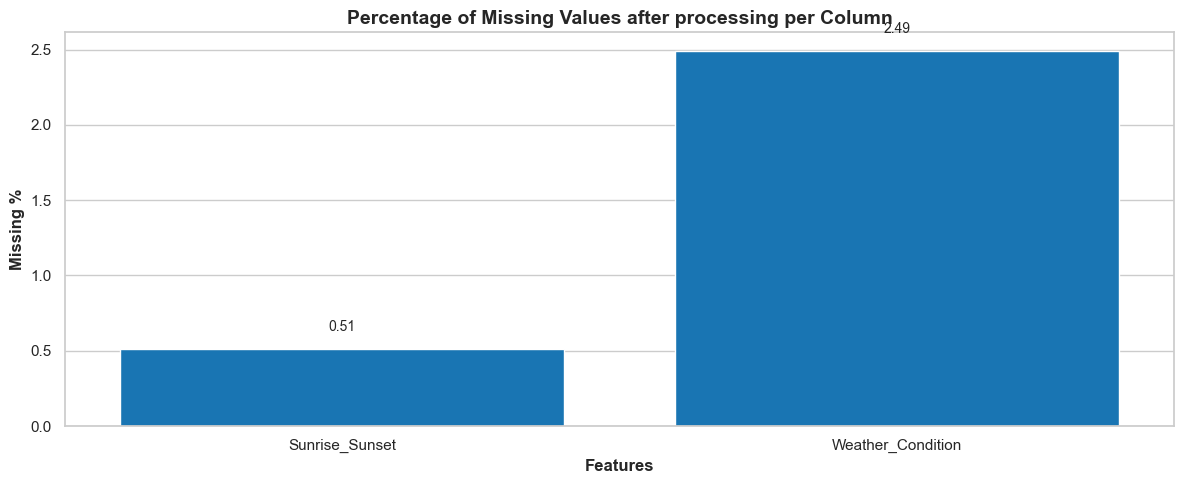

In [79]:
missing_plot = missing_percent[missing_percent > 0] 
plt.figure(figsize=(12,5))
ax = sns.barplot(x=missing_plot.index, y=missing_plot.values, color='#007acc')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0, ha='center')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Missing %', fontsize=12, fontweight='bold')
plt.title('Percentage of Missing Values after processing per Column', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Outlier Detection**


In [48]:
# Detect outliers using the IQR method
Q1 = df_train[numerical_vars].quantile(0.25)
Q3 = df_train[numerical_vars].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_train[numerical_vars] < (Q1 - 1.5 * IQR)) | 
              (df_train[numerical_vars] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Temperature(F)     22123
Humidity(%)            0
Visibility(mi)    462300
Severity          169713
dtype: int64


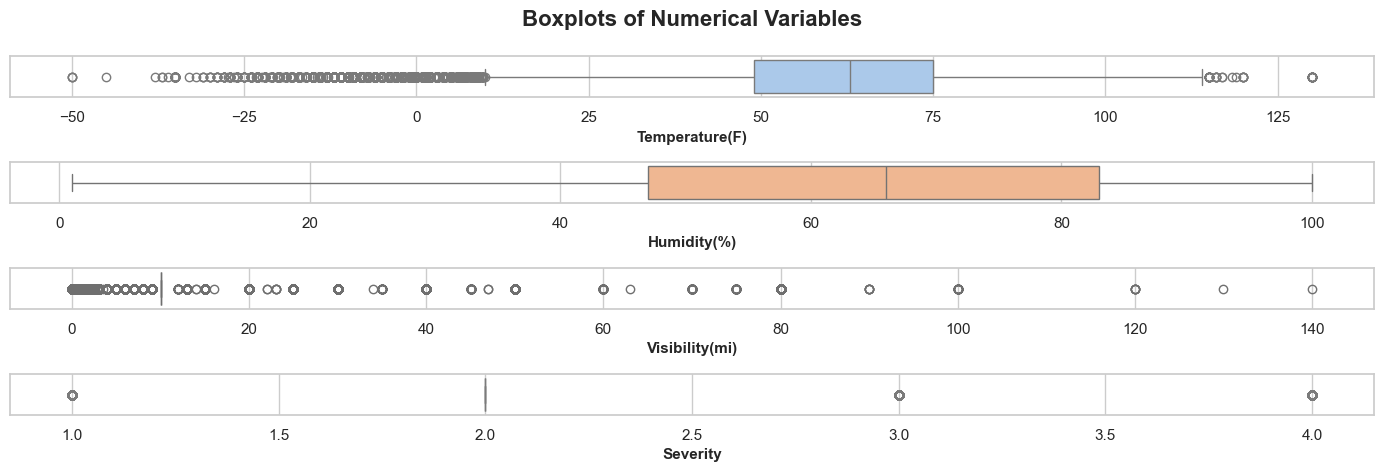

In [50]:
n = len(numerical_vars)

plt.figure(figsize=(14, n * 1.2))

for i, col in enumerate(numerical_vars, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df_train[col],
        orient='h',
        color=palette_color[i - 1]
    )
    plt.xlabel(col, fontweight='bold', fontsize=11)

plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

After cleaning, the number of outliers decreases in some fields (**Temperature(F), Severity**) due to transformations or filtering.
However, **Visibility(mi)** still contains many outliers. These values were not removed intentionally, because low visibility is a realistic condition in accident scenarios and directly contributes to crash risk. These are meaningful observations, not invalid data points, so they remain in the dataset.

## VIF Check

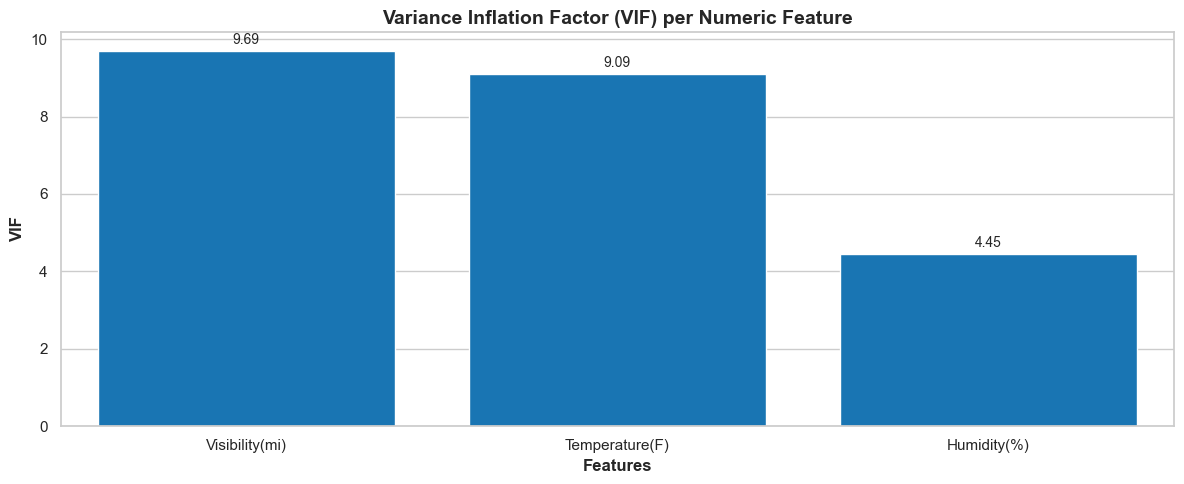

In [51]:
target_var = 'Severity'
X_numeric = df_train[numerical_vars].drop(columns=[target_var])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.dropna().values, i) 
                   for i in range(X_numeric.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(x='Feature', y='VIF', data=vif_data, color='#007acc')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)
    
plt.xticks(rotation=0, ha='center')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('VIF', fontsize=12, fontweight='bold')
plt.title('Variance Inflation Factor (VIF) per Numeric Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

After cleaning and processing, only three core numeric features remained for VIF testing.
- **Visibility** and **Temperature** have VIF close to 10, showing strong multicollinearity, meaning these weather variables still influence each other even after processing.
- **Humidity** has moderate correlation.
> Overall, the processed dataset is cleaner but still shows expected relationships between weather metrics.

## **Numerical features distribution**

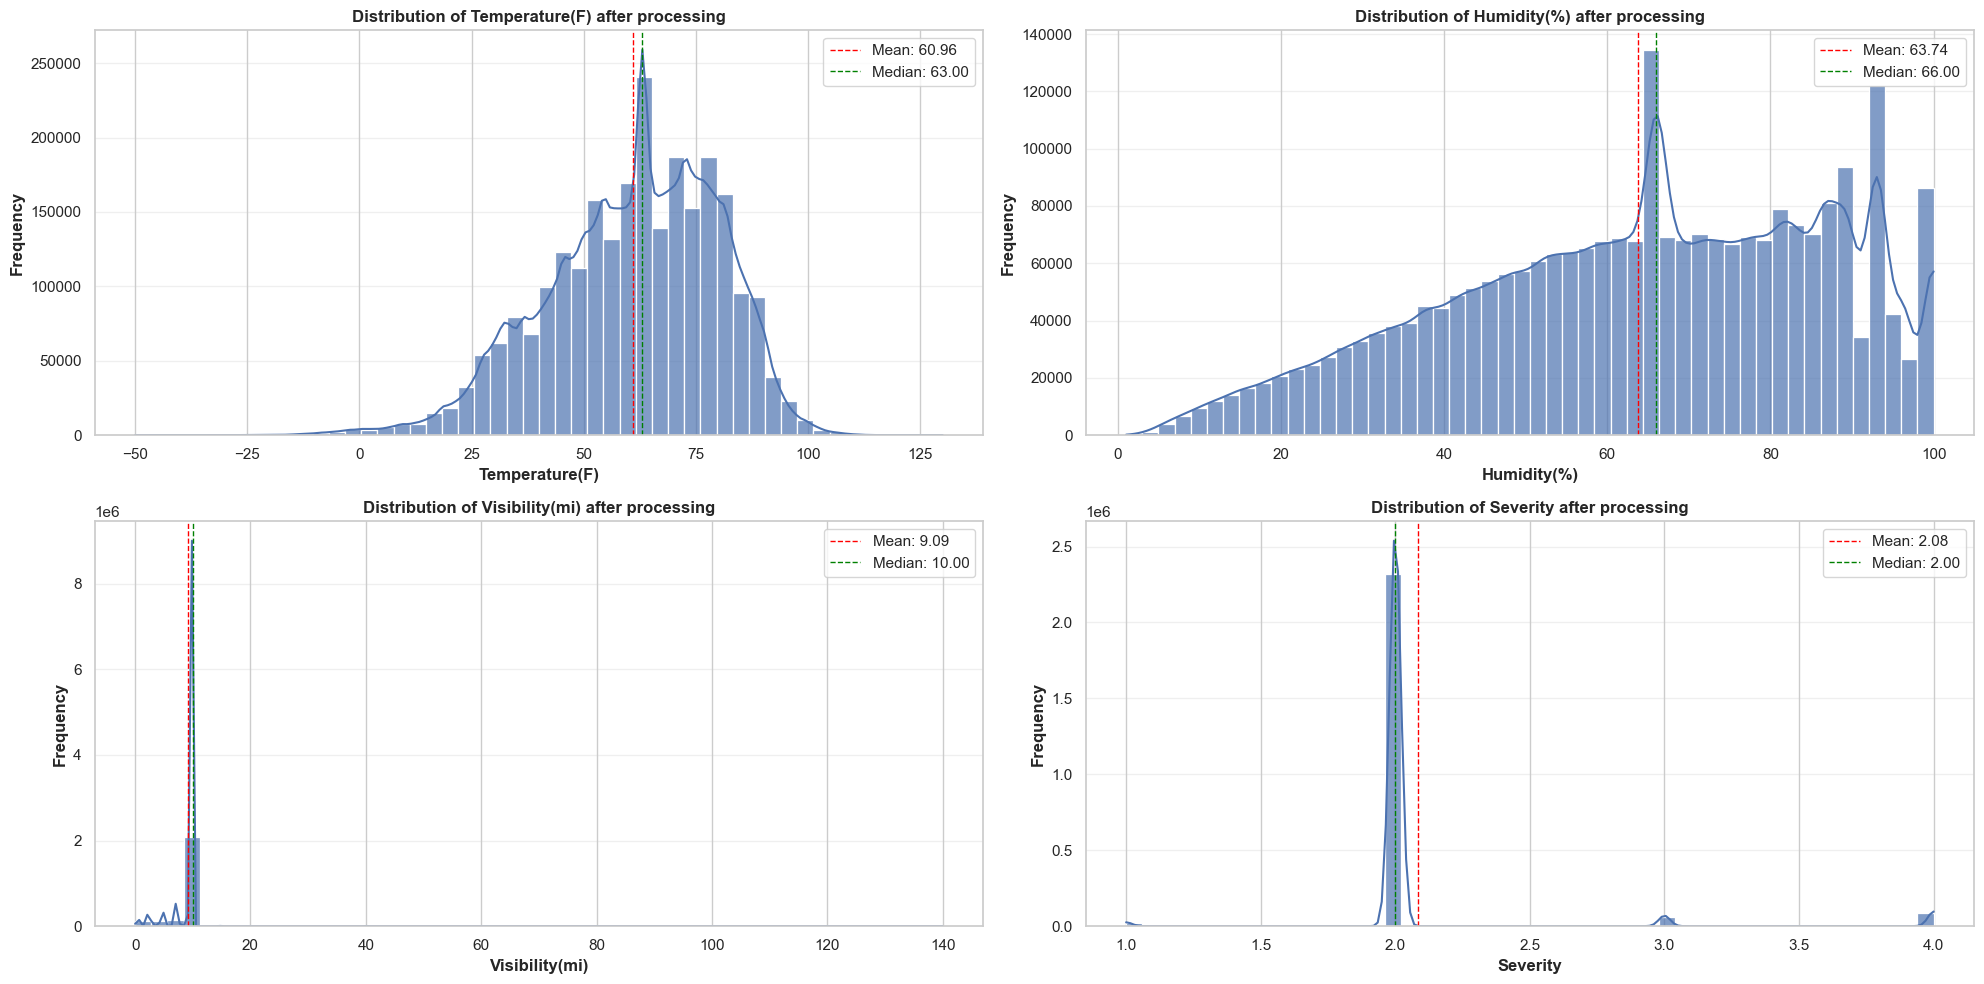

In [77]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

n_cols = len(numerical_cols)
n_rows = n_cols // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(df_train[col], kde=True, bins=50, ax=axes[idx], alpha=0.7)
        axes[idx].set_title(f'Distribution of {col} after processing', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add mean and median lines
        axes[idx].axvline(df_train[col].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df_train[col].mean():.2f}')
        axes[idx].axvline(df_train[col].median(), color='green', linestyle='--', linewidth=1, label=f'Median: {df_train[col].median():.2f}')

        axes[idx].legend(loc='upper right')

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**Overall Summary**

The mean and median indices are almost unchanged after processing for most variables (**Temperature, Humidity, Visibility, Severity**) — that is, processing does not change the center of the data much.
The most obvious difference is in the tails/outliers and the shape of the distribution: after processing the data looks “cleaner”, the unusual tails are reduced/removed, the density line is smoother — this makes the learning model more stable.
Details by variable

**Temperature (F)**
Before processing: the distribution is approximately normal but has a left tail (large negative/negative values) and some unusual values ​​at both ends; mean ≈ 60.90, median = 63.
After processing: mean ≈ 60.96, median = 63 — the center remains unchanged. However, the abnormal left tail is reduced/eliminated and the distribution around 50–80 is clearer, the density is smoother.
> The treatment mainly removes/aggregates the extreme (unreasonable) temperature values, keeping the central information.

**Humidity (%)**
Before treatment: the distribution gradually increases to ~60–100, with fluctuations/peaks near 100 (many 100 values), mean ≈ 63.68, median = 66.
After treatment: mean ≈ 63.74, median = 66 — almost unchanged. The post-treatment distribution is smoother, less noise in the low/mid range, spikes/fluctuations are still present in the high range (near 90–100).
> The treatment keeps the overall structure of humidity, removes small noise and smooths the density but still leaves clusters of high values ​​(which may be real/highly recorded).


**Visibility (mi)**
Before treatment: distribution is very right skewed — mostly concentrated at low levels (near 10 mi or lower) but there are some large outliers causing long tails; mean ≈ 9.07, median = 10.
After treatment: mean ≈ 9.09, median = 10 — center unchanged; post-treatment distribution is similarly right skewed but density curve is smoother, extremely large tails may have been treated/denoised.
> Treatment did not change the center position, but cleaned up large outliers/unwanted fluctuations.

**Severity**
Before treatment: distribution is scattered but strongly concentrated at value 2 (mean ≈ 2.08, median = 2), with a few observations at 3 and 4.
After treatment: mean and median remain the same, distribution shape remains similar — i.e. no major structural changes for this variable.
> Severity variable is stable, not much affected by the processing step (maybe because it is categorical/ordinal and has few missing/outliers).

**Distance (mi)**
Only appears in the “before processing” chart: extremely right-skewed distribution, mostly in very small ranges (<1 mi) with a few very large outliers (creating a long tail); mean ≈ 0.82, median ≈ 0.25.
In the “after processing” image, Distance variable is not plotted (maybe removed or transformed). If removed, it is because the distribution is too skewed and/or has many errors/outliers.
> Distance has many outliers and the distribution is not favorable for straight modeling; special treatment is needed if retained.

## **Categorical features distribution**

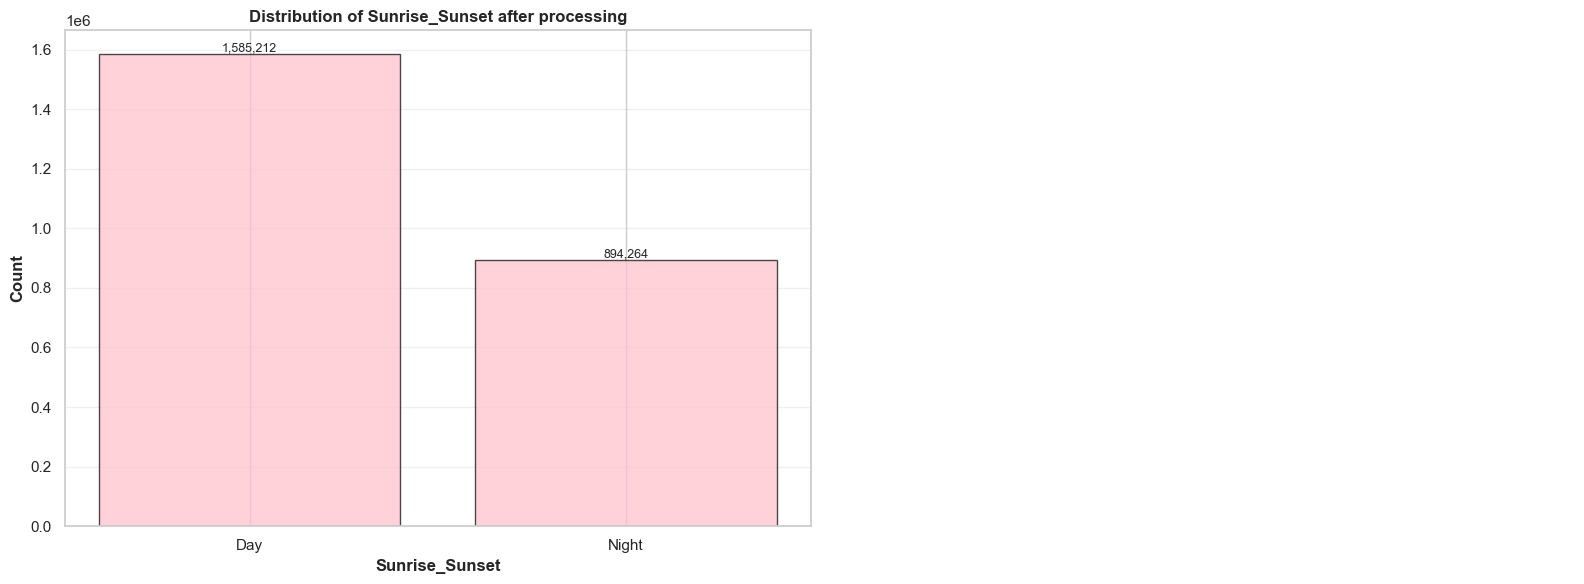

In [80]:
categorical_cols = df_train.select_dtypes(include=['object']).columns.drop(['Start_Time', 'City', 'County', 'State', 'Weather_Condition'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df_train[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='pink', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col} after processing', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontweight='bold')
        axes[idx].set_ylabel('Count', fontweight='bold')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=0, ha='center')
        axes[idx].grid(axis='y', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Hide extra subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## **Numerical Features vs Severity**

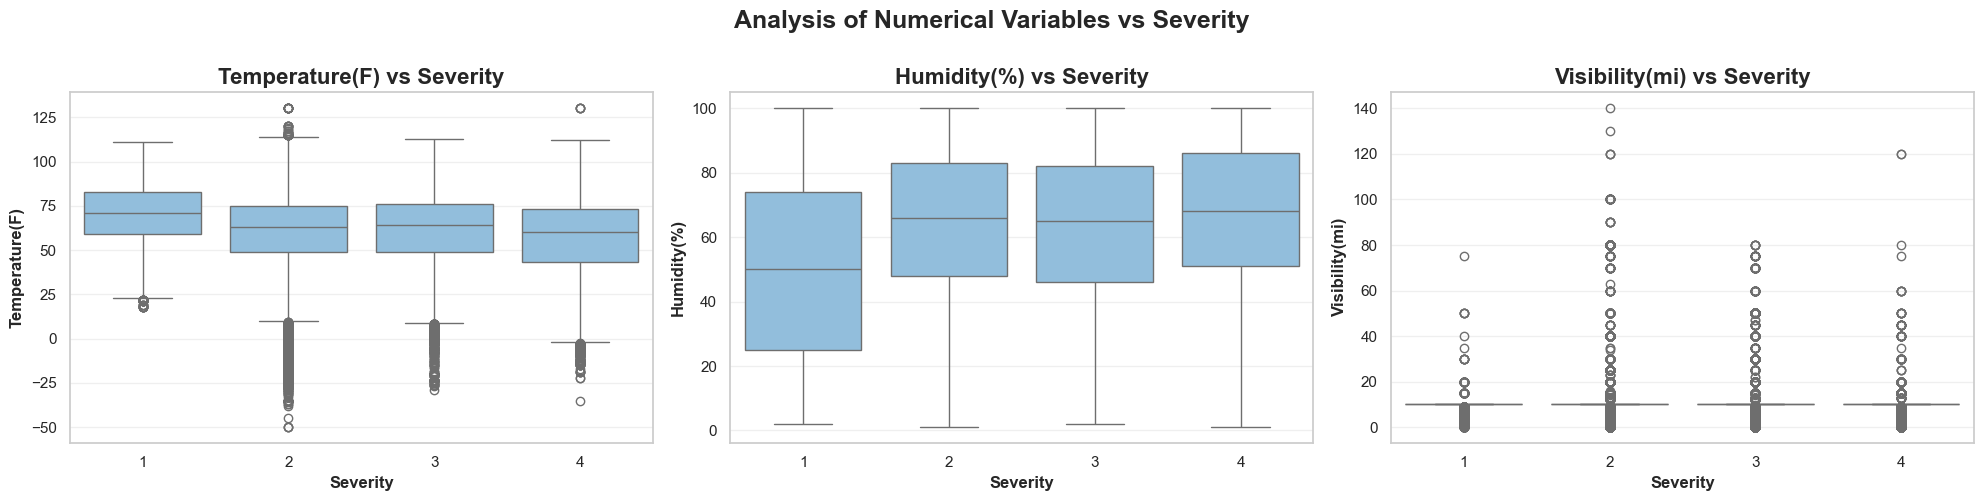

In [57]:
numerical_cols_for_analysis = df_train.select_dtypes(include=['int64', 'float64']).columns.drop(['Severity']).tolist()

n_cols = len(numerical_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols_for_analysis):
    if idx < len(axes):
        sns.boxplot(data=df_train, x='Severity', y=col, 
                    ax=axes[idx], 
                    color='#85C1E9',
                    showfliers=True) 
        
        axes[idx].set_title(f'{col} vs Severity', fontsize=16, fontweight='bold')
        axes[idx].set_xlabel('Severity', fontweight='bold', fontsize=12)
        axes[idx].set_ylabel(col, fontweight='bold', fontsize=12)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_cols_for_analysis), len(axes)):
    axes[idx].axis('off')
    
plt.suptitle('Analysis of Numerical Variables vs Severity', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

## **Categorical Features vs Severity**

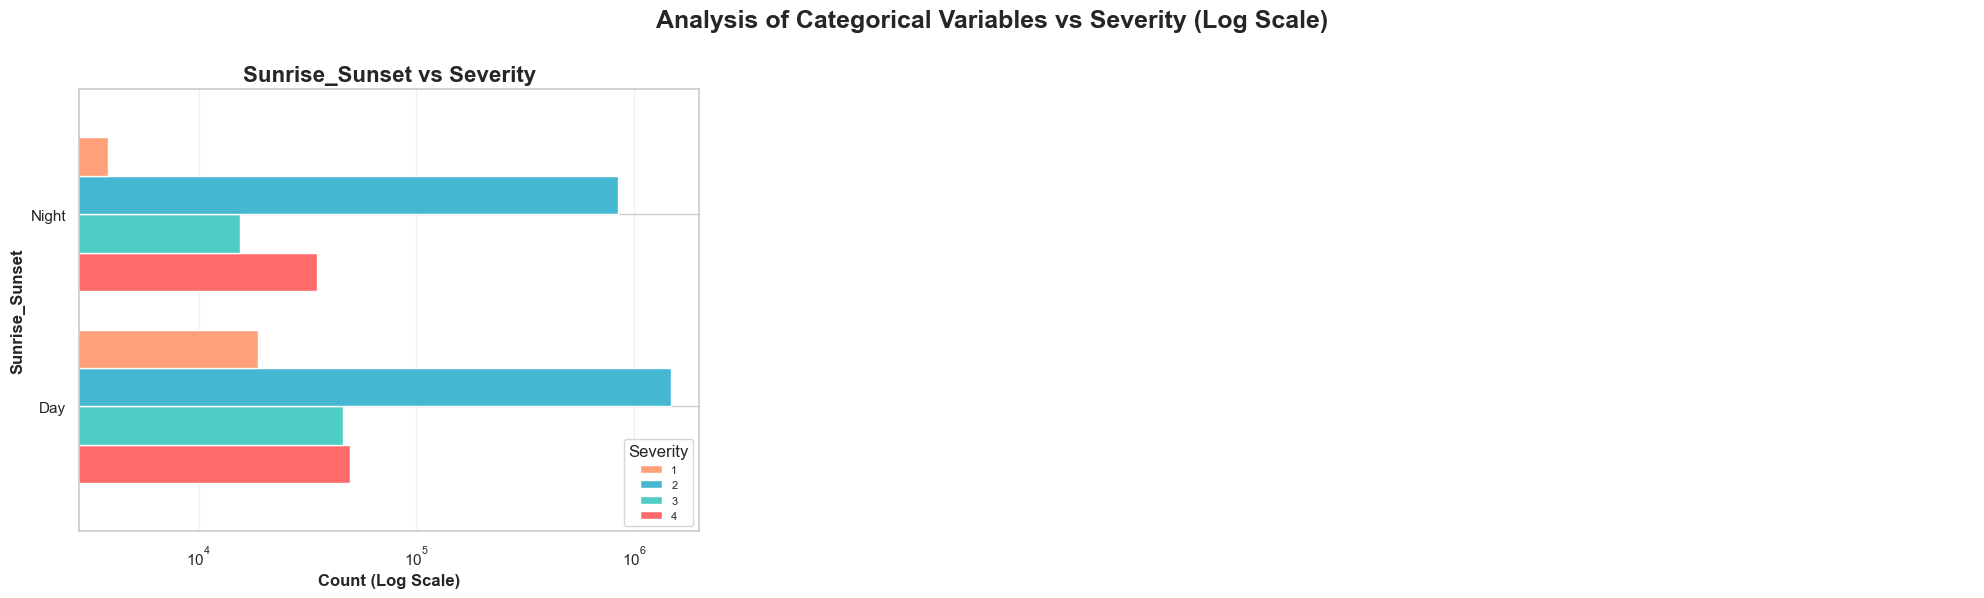

In [59]:
categorical_cols_for_analysis = df_train.select_dtypes(include=['object']).columns.drop(['Start_Time', 'City', 'County', 'State', 'Weather_Condition']).tolist()

n_cols = len(categorical_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 6)) 
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, feature in enumerate(categorical_cols_for_analysis):
    if idx < len(axes):
        if df_train[feature].nunique() > 10:
            top_categories = df_train[feature].value_counts().head(10).index
            top_categories = top_categories[::-1]
            plot_df = df_train[df_train[feature].isin(top_categories)]
            title_suffix = ' (Top 10)'
        else:
            plot_df = df_train
            title_suffix = ''
        
        severity_counts = plot_df.groupby([feature, 'Severity']).size().unstack(fill_value=0)

        if df_train[feature].nunique() > 10:
             severity_counts = severity_counts.reindex(top_categories)
        
        severity_counts = severity_counts.reindex(columns=[1, 2, 3, 4], fill_value=0)
        severity_counts = severity_counts[[4, 3, 2, 1]]

        severity_counts.plot(kind='barh', ax=axes[idx], stacked=False, 
                             logx=True, width=0.8,
                             color=colors)
        
        axes[idx].set_title(f'{feature} vs Severity{title_suffix}', fontsize=16, fontweight='bold')
        axes[idx].set_ylabel(feature, fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Count (Log Scale)', fontweight='bold', fontsize=12)
        axes[idx].tick_params(axis='y', labelsize=11)

        handles, labels = axes[idx].get_legend_handles_labels()
        axes[idx].legend(handles[::-1], labels[::-1], title='Severity', fontsize=8, loc='lower right')
        
        axes[idx].grid(axis='x', alpha=0.3)

# Hide extra subplot
for i in range(len(categorical_cols_for_analysis), len(axes)):
    axes[i].axis('off')

plt.suptitle('Analysis of Categorical Variables vs Severity (Log Scale)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## **Correlation Matrix**

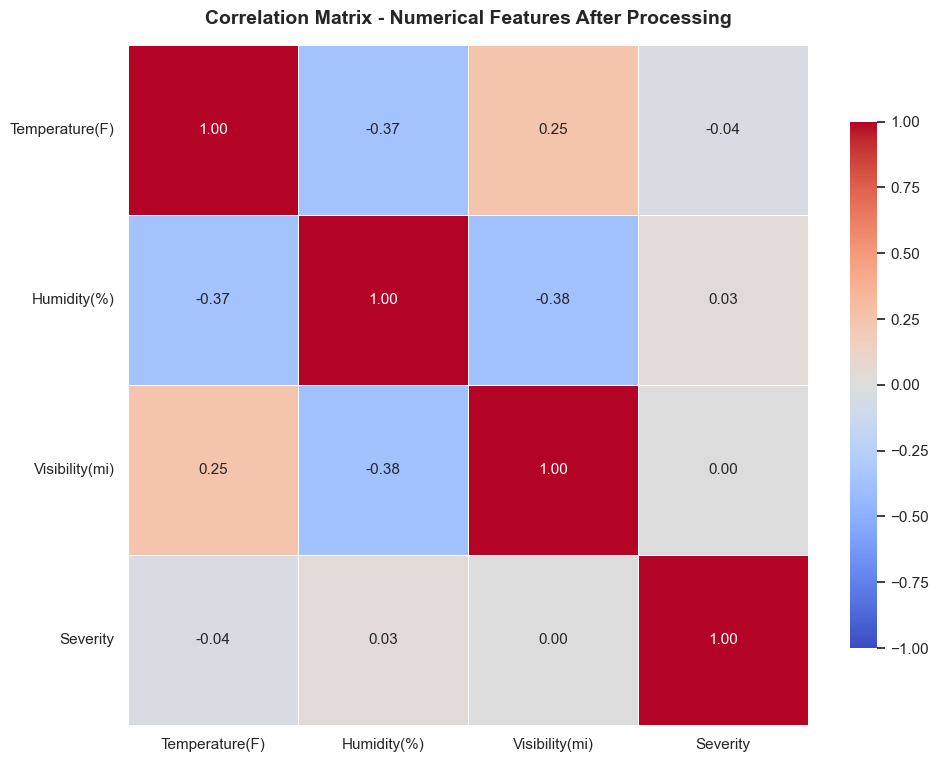

Highly Correlated Feature Pairs (|correlation| > 0.7)

No feature pairs with |correlation| > 0.7 found.


In [81]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=-1, vmax=1,
            annot_kws={"size": 11})

plt.title('Correlation Matrix - Numerical Features After Processing', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Highly Correlated Feature Pairs (|correlation| > 0.7)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1:30s} <-> {var2:30s} : {corr:7.3f}")
else:
    print("\nNo feature pairs with |correlation| > 0.7 found.")

Post-processing retains the main weather variables (**Temperature, Humidity, Visibility**) and **Severity**; the geographical variables (**Latitude/Longitude/Distance**) do not appear in the post-processing matrix.

Central parameters are almost unchanged: Temperature mean ≈ 60.96, median = 63; Humidity mean ≈ 63.74, median = 66; Visibility mean ≈ 9.09, median = 10; Severity mean ≈ 2.08, median = 2.

**Distribution & post-processing changes**
**Temperature**: two-tailed outliers are reduced/removed, distribution is smoother around 50–80.
**Humidity**: distribution is smoother; large spikes remain in the high region (90–100) if it is real data.
**Visibility**: extremely large tails are cleaned/denoised; The distribution is still skewed right but “cleaner”.
**Distance**: has been removed/removed from the analysis (due to too large skew/outlier), so it does not appear in the processed EDA.

**Correlation (after processing)**
The relationships between Weather features remain: **Temp–Hum** ≈ -0.37, **Hum–Vis** ≈ -0.38, **Temp–Vis** ≈ 0.25.
**Severity** is still almost not linearly correlated with these variables (**Severity–Temp** ≈ -0.04, –Hum ≈ 0.03, –Vis ≈ 0.00).

> Comment: data processing has cleaned but does not change the nature of the linear relationship between features and targets.